# Notebook 06 — LGD, EAD and Expected Credit Loss (ECL)

## What are we doing in this notebook?

So far we have built a **PD model** — the probability that a borrower defaults.  
However, PD alone does not tell us **how much money we expect to lose**.

To estimate losses, we need all three components of the Basel credit risk framework:

$$\text{ECL} = PD \times LGD \times EAD$$

| Component | What it means | How we get it |
|-----------|--------------|---------------|
| **PD** | Probability that a borrower defaults | Already built (Notebook 04) — loaded from saved model |
| **LGD** | Loss Given Default — proportion of exposure lost after default | Two-stage model built in this notebook |
| **EAD** | Exposure at Default — outstanding loan balance at time of default | Linear regression on CCF (this notebook) |
| **ECL** | Expected Credit Loss — expected monetary loss per loan | PD × LGD × EAD |

---

## Why we need the RAW data file here

The cleaned dataset (`loan_data_cleaned.csv`) was built specifically for the **PD model**.  
During PD preparation, we intentionally removed **post-default variables** to avoid data leakage:
- `recoveries` — money recovered after default
- `total_rec_prncp` — principal recovered

These are essential for LGD and EAD targets.  
So we go back to the **raw Lending Club file** for this notebook.

---

## Key modelling principle

- **LGD and EAD models** → trained only on defaulted loans (we can only observe recovery after default)
- **ECL calculation** → all three models applied to the **full dataset** (every loan needs an ECL estimate)

This is standard Basel IRB practice:  
LGD and EAD are estimated from historical defaults, then applied forward to the entire portfolio.

---
# PART 1 — Setup and Data Loading

In [1]:
# =========================================================
# IMPORTS
# =========================================================
# numpy        : array operations and math
# pandas       : dataframe operations
# matplotlib   : plotting
# seaborn      : better looking plots
# sklearn      : model building, train/test split, metrics
# scipy.stats  : p-value calculations
# pickle       : save and load trained models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import roc_curve, roc_auc_score, r2_score, mean_squared_error

import scipy.stats as stat
import pickle
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set()

print('Libraries loaded.')

Libraries loaded.


In [2]:
# =========================================================
# LOAD RAW DATA
# =========================================================
# We load the raw Lending Club file — not the cleaned one.
# Reason: the cleaned file had 'recoveries' and 'total_rec_prncp'
# removed to prevent data leakage in the PD model.
# For LGD and EAD, these columns ARE the targets — we need them.

raw = pd.read_csv(r'C:\Users\amit_\Github\credit-portfolio-vasicek-simulation\data\raw\loan_data.csv')
print('Raw data shape:', raw.shape)

Raw data shape: (466285, 75)


In [3]:
# =========================================================
# FILTER TO DEFAULTED LOANS ONLY
# =========================================================
# LGD and EAD are modelled ONLY on loans that have already defaulted.
# We can only observe recovery_rate and CCF AFTER a default happens.
# 'Charged Off' = the bank wrote off the loan as unrecoverable.
# The second status is the older policy-based equivalent in Lending Club data.

defaults = raw[raw['loan_status'].isin([
    'Charged Off',
    'Does not meet the credit policy. Status:Charged Off'
])].copy()

print('Defaulted loans:', defaults.shape[0])
print('Columns:', defaults.shape[1])

Defaulted loans: 43236
Columns: 75


---
# PART 2 — Feature Engineering on Defaults Dataset

We apply the same preprocessing logic as the PD model (Notebook 01), but on the defaults subset only.

Steps:
1. Convert `term`, `emp_length`, `issue_d`, `earliest_cr_line` to numeric
2. Handle missing values
3. Create dummy variables for categorical columns
4. Create target variables: `recovery_rate`, `CCF`, `LGD`, `rec_flag`
5. Drop invalid rows

In [4]:
# =========================================================
# FEATURE ENGINEERING — DEFAULTS DATASET
# =========================================================

df = defaults.copy()

# ---------------------------------------------------------
# 0. SAFETY: ensure key financial columns are numeric
# ---------------------------------------------------------
df['recoveries']  = pd.to_numeric(df['recoveries'],  errors='coerce')
df['funded_amnt'] = pd.to_numeric(df['funded_amnt'], errors='coerce')
df = df[df['funded_amnt'] > 0]   # remove any rows with zero or missing loan amount

# ---------------------------------------------------------
# 1. TERM: strip text, keep number
#    '36 months' → 36
# ---------------------------------------------------------
df['term_month'] = pd.to_numeric(
    df['term'].str.replace(r'[^0-9]', '', regex=True), errors='coerce'
)

# ---------------------------------------------------------
# 2. EMPLOYMENT LENGTH: strip text, keep number
#    '10+ years' → 10 | '< 1 year' → 0 | 'n/a' → 0
# ---------------------------------------------------------
df['emp_length_years'] = (
    df['emp_length'].str.strip()
      .replace({'< 1 year': '0', 'n/a': '0'})
      .str.replace(r'[^0-9]', '', regex=True)
)
df['emp_length_years'] = pd.to_numeric(df['emp_length_years'], errors='coerce')

# ---------------------------------------------------------
# 3. DATE FEATURES
#    We measure 'months since' from a fixed reference date (Dec 2016)
#    so the numbers are stable and do not change with time
# ---------------------------------------------------------
ref = pd.to_datetime('2016-12-01')

df['earliest_cr_dt'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%y', errors='coerce')
df['months_since_earliest_cr_line'] = (
    (ref.year  - df['earliest_cr_dt'].dt.year)  * 12 +
    (ref.month - df['earliest_cr_dt'].dt.month)
).clip(lower=0)

df['issue_dt'] = pd.to_datetime(df['issue_d'], format='%b-%y', errors='coerce')
df['months_since_issue_date'] = (
    (ref.year  - df['issue_dt'].dt.year)  * 12 +
    (ref.month - df['issue_dt'].dt.month)
)

# ---------------------------------------------------------
# 4. MISSING VALUE HANDLING
#    For 'months since last delinquency' — if missing,
#    the borrower has never been delinquent, so we fill with 0.
#    For total_rev_hi_lim — fill with median.
# ---------------------------------------------------------
df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(0)
df['mths_since_last_record'] = df['mths_since_last_record'].fillna(0)
df['total_rev_hi_lim']       = df['total_rev_hi_lim'].fillna(df['total_rev_hi_lim'].median())

# ---------------------------------------------------------
# 5. TARGET VARIABLES
# ---------------------------------------------------------

# recovery_rate = how much of the loan was recovered after default
# Clipped to [0,1] — can't recover more than 100% or less than 0%
df['recoveries']    = df['recoveries'].fillna(0)
df['recovery_rate'] = (df['recoveries'] / df['funded_amnt']).clip(0, 1)
df['LGD']           = 1 - df['recovery_rate']

# rec_flag = binary: did ANY recovery happen? (Stage 1 LGD target)
df['rec_flag'] = np.where(df['recovery_rate'] > 0, 1, 0)

# CCF = fraction of loan still unpaid at default (EAD target)
# CCF = (funded - principal_recovered) / funded
df['total_rec_prncp'] = pd.to_numeric(df['total_rec_prncp'], errors='coerce').fillna(0)
df['CCF'] = ((df['funded_amnt'] - df['total_rec_prncp']) / df['funded_amnt']).clip(0, 1)

# ---------------------------------------------------------
# 6. DUMMY VARIABLES for categorical columns
#    pd.get_dummies converts 'grade' into grade:A, grade:B, etc.
#    We rename with ':' separator to match standard convention
# ---------------------------------------------------------
cat_cols = ['grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status']

df_model = pd.get_dummies(df, columns=cat_cols, prefix=cat_cols, drop_first=False)

rename_map = {}
for col in df_model.columns:
    for p in cat_cols:
        if col.startswith(p + '_'):
            rename_map[col] = col.replace(p + '_', p + ':', 1)
df_model.rename(columns=rename_map, inplace=True)

# ---------------------------------------------------------
# 7. CLEAN: remove infinities and drop invalid rows
# ---------------------------------------------------------
df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna(subset=['LGD', 'recovery_rate', 'CCF', 'term_month', 'emp_length_years'])

print('Pipeline complete.')
print('Shape:', df_model.shape)
print('\nLGD summary:')
print(df_model['LGD'].describe().round(4))
print('\nRecovery flag distribution:')
print(df_model['rec_flag'].value_counts())

Pipeline complete.
Shape: (40899, 111)

LGD summary:
count    40899.0000
mean         0.9386
std          0.0898
min          0.0000
25%          0.8855
50%          0.9682
75%          1.0000
max          1.0000
Name: LGD, dtype: float64

Recovery flag distribution:
rec_flag
1    23303
0    17596
Name: count, dtype: int64


---
# PART 3 — Visualise Target Variables

Before modelling, always look at the distribution of what you are trying to predict.

**Recovery Rate (LGD target):**  
You will see a large spike at 0 — many defaulted loans have zero recovery.  
This bimodal shape (spike at 0 + continuous distribution above 0) is exactly why we need a two-stage LGD model.

**CCF (EAD target):**  
More spread out — no dominant spike — so a single linear regression works fine.

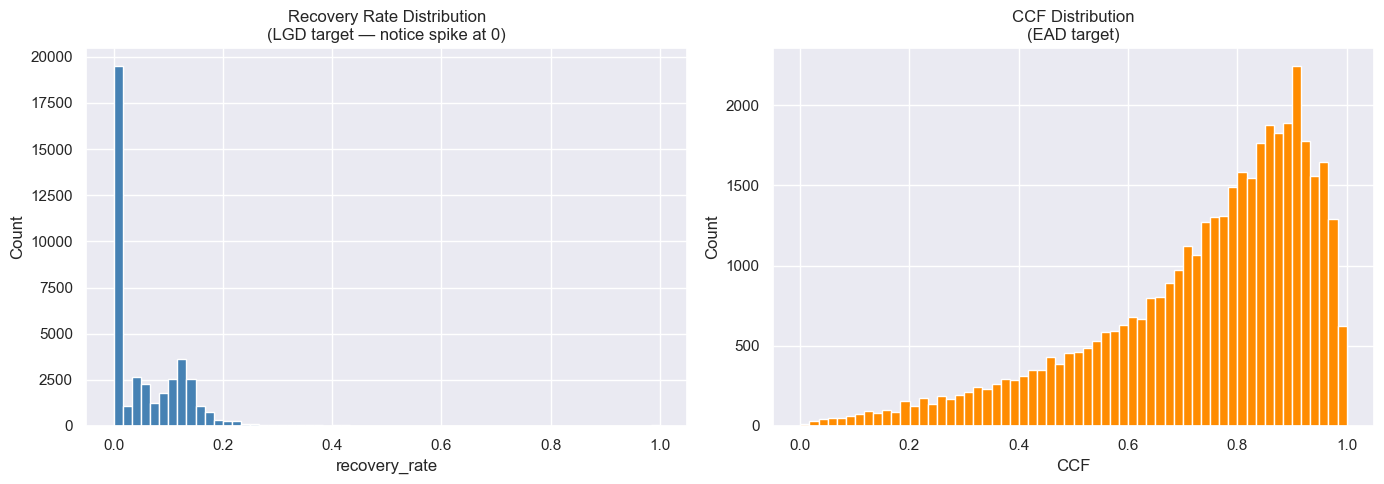

Zero recovery:     17596  (43.0%)
Non-zero recovery: 23303  (57.0%)


In [5]:
# =========================================================
# VISUALISE TARGETS
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_model['recovery_rate'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Recovery Rate Distribution\n(LGD target — notice spike at 0)')
axes[0].set_xlabel('recovery_rate')
axes[0].set_ylabel('Count')

axes[1].hist(df_model['CCF'], bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('CCF Distribution\n(EAD target)')
axes[1].set_xlabel('CCF')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

zero_rec    = (df_model['recovery_rate'] == 0).sum()
nonzero_rec = (df_model['recovery_rate'] > 0).sum()
print(f'Zero recovery:     {zero_rec}  ({100*zero_rec/len(df_model):.1f}%)')
print(f'Non-zero recovery: {nonzero_rec}  ({100*nonzero_rec/len(df_model):.1f}%)')

---
# PART 4 — Define Feature Set

We define which borrower characteristics to use as predictors in LGD and EAD models.

**Dummy variable trap:**  
When we have 7 grade dummies (A through G), we only need 6 in the model.  
The 7th is perfectly implied when all others are 0.  
Including all 7 causes multicollinearity — coefficients become unreliable.  
So we drop one **reference category** per group.

In [6]:
# =========================================================
# FEATURE LIST
# =========================================================
# All candidate features — borrower characteristics and loan attributes
# that may influence how much is recovered after default

features = [
    'grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F', 'grade:G',
    'home_ownership:MORTGAGE', 'home_ownership:NONE', 'home_ownership:OTHER',
    'home_ownership:OWN', 'home_ownership:RENT',
    'verification_status:Not Verified', 'verification_status:Source Verified',
    'verification_status:Verified',
    'purpose:car', 'purpose:credit_card', 'purpose:debt_consolidation',
    'purpose:educational', 'purpose:home_improvement', 'purpose:house',
    'purpose:major_purchase', 'purpose:medical', 'purpose:moving',
    'purpose:other', 'purpose:renewable_energy', 'purpose:small_business',
    'purpose:vacation', 'purpose:wedding',
    'initial_list_status:f', 'initial_list_status:w',
    'term_month', 'emp_length_years', 'months_since_issue_date',
    'months_since_earliest_cr_line',
    'funded_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
    'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq',
    'mths_since_last_record', 'open_acc', 'pub_rec', 'total_acc',
    'acc_now_delinq', 'total_rev_hi_lim'
]

# Keep only features that actually exist in our dataframe
features = [f for f in features if f in df_model.columns]
print(f'Features available: {len(features)}')

# Reference categories to drop (one per dummy group)
# These become the baseline — all other categories are interpreted relative to them
ref_cats = [
    'grade:G',
    'home_ownership:RENT',
    'verification_status:Verified',
    'purpose:credit_card',
    'initial_list_status:f'
]

features_final = [f for f in features if f not in ref_cats]
print(f'Features after dropping reference categories: {len(features_final)}')

# Drop rows with missing values in any feature column
df_model = df_model.dropna(subset=features_final)
print(f'Shape after dropping NAs: {df_model.shape}')

Features available: 49
Features after dropping reference categories: 44
Shape after dropping NAs: (40896, 111)


---
# PART 5 — Custom Model Classes with P-Values

Sklearn's LogisticRegression and LinearRegression do not provide p-values.

P-values tell us whether a variable is statistically significant:  
- p-value < 0.05 → the variable contributes meaningfully to the model  
- p-value > 0.05 → the variable may just be noise

We build two wrapper classes that add p-value computation on top of sklearn.

In [7]:
# =========================================================
# CUSTOM CLASS 1 — LOGISTIC REGRESSION WITH P-VALUES
# =========================================================

class LogitWithPValues:
    """
    Logistic Regression with p-value computation.

    sklearn's LogisticRegression gives coefficients but no p-values.
    This class wraps it and computes p-values using the
    Fisher Information Matrix (FIM) approach:

    1. FIM captures how much 'information' data carries about each parameter
    2. Covariance matrix = inverse of FIM (Cramer-Rao bound)
    3. Standard error = sqrt of diagonal of covariance matrix
    4. z-score = coefficient / standard error
    5. p-value = two-tailed test from normal distribution

    Attributes:
        model       : underlying sklearn LogisticRegression
        coef_       : model coefficients
        intercept_  : model intercept
        p_values    : list of p-values for each coefficient
    """

    def __init__(self, *args, **kwargs):
        self.model = linear_model.LogisticRegression(*args, **kwargs)

    def fit(self, X, y):
        """
        Fit the logistic regression and compute p-values.

        Parameters:
            X : numpy array — feature matrix (must be numeric)
            y : numpy array — binary target (0 or 1)
        """
        self.model.fit(X, y)

        decision = np.clip(self.model.decision_function(X), -500, 500)
        denom    = 2.0 * (1.0 + np.cosh(decision))
        denom    = np.tile(denom, (X.shape[1], 1)).T

        # Fisher Information Matrix + small ridge for numerical stability
        fim = np.dot((X / denom).T, X) + np.eye(X.shape[1]) * 1e-6
        cov = np.linalg.inv(fim)
        se  = np.sqrt(np.diagonal(cov))
        z   = self.model.coef_[0] / se

        self.p_values   = [stat.norm.sf(abs(zi)) * 2 for zi in z]
        self.coef_      = self.model.coef_
        self.intercept_ = self.model.intercept_
        return self


# =========================================================
# CUSTOM CLASS 2 — LINEAR REGRESSION WITH P-VALUES
# =========================================================

class LinearRegWithPValues(linear_model.LinearRegression):
    """
    Linear Regression with t-statistics and p-values.

    Extends sklearn's LinearRegression.
    After fitting, computes:

    1. SSE = sum of squared residuals / (n - k) — unbiased variance estimate
    2. Standard error = sqrt(SSE * (X'X)^-1)
    3. t-statistic = coefficient / standard error
    4. p-value = two-tailed t-distribution test with (n - k) degrees of freedom

    Attributes:
        t : t-statistics for each coefficient
        p : p-values for each coefficient
    """

    def fit(self, X, y):
        """
        Fit linear regression and compute p-values.

        Parameters:
            X : numpy array — feature matrix
            y : numpy array — continuous target
        """
        super().fit(X, y)
        n, k  = X.shape
        sse   = np.sum((self.predict(X) - y) ** 2) / float(n - k)
        XtX   = np.dot(X.T, X) + np.eye(k) * 1e-6   # small ridge for stability
        se    = np.sqrt(np.diagonal(sse * np.linalg.inv(XtX)))
        self.t = self.coef_ / se
        self.p = np.squeeze(2 * (1 - stat.t.cdf(np.abs(self.t), df=n - k)))
        return self


print('Custom model classes defined.')

Custom model classes defined.


---
# PART 6 — LGD MODEL (Two-Stage Approach)

## Why two stages?

The recovery_rate distribution has a large spike at 0 — roughly 50-60% of defaulted loans have zero recovery.  
The remaining 40-50% have positive recovery spread across (0, 1].

A single regression would be dominated by the zeros and would fail to model positive recoveries properly.

**Two-Part (Hurdle) Model:**
- **Stage 1 (Logistic):** Will ANY recovery happen? → predicts P(recovery > 0)
- **Stage 2 (Linear):** How much? → trained only on loans where recovery > 0
- **Combined:** predicted_recovery = P(recovery) × predicted_amount → LGD = 1 − predicted_recovery

In [8]:
# =========================================================
# TRAIN / TEST SPLIT
# =========================================================
# X = features | y_s1 = binary rec_flag | y_s2 = continuous recovery_rate
# Same random_state=42 split used for both stages
# so that train and test rows are consistent across Stage 1 and Stage 2

X    = df_model[features_final].astype(float)
y_s1 = df_model['rec_flag']
y_s2 = df_model['recovery_rate']

X_train, X_test, y1_train, y1_test = train_test_split(
    X, y_s1, test_size=0.2, random_state=42
)

# Align Stage 2 target to same row indices as the split above
y2_train = y_s2.loc[X_train.index]
y2_test  = y_s2.loc[X_test.index]

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

Train: 32716 rows | Test: 8180 rows


## Stage 1 — Logistic Regression (Will any recovery happen?)

In [9]:
# =========================================================
# LGD STAGE 1 — LOGISTIC REGRESSION
# =========================================================
# Target: rec_flag (0 = no recovery, 1 = some recovery)
# max_iter=1000 to ensure convergence on a large feature set

lgd_s1 = LogitWithPValues(max_iter=1000)
lgd_s1.fit(X_train.values, y1_train.values)

# Build summary table — coefficients and p-values for each feature
feat_names = X_train.columns.values

s1_summary = pd.DataFrame({'Feature': feat_names, 'Coefficient': lgd_s1.coef_[0]})
s1_summary.index = s1_summary.index + 1
s1_summary.loc[0] = ['Intercept', lgd_s1.intercept_[0]]
s1_summary = s1_summary.sort_index()
s1_summary['p_value'] = np.append(np.nan, np.array(lgd_s1.p_values)).round(4)

print('Stage 1 — Significant features (p < 0.05):')
print(s1_summary[s1_summary['p_value'] < 0.05].to_string())

Stage 1 — Significant features (p < 0.05):
                          Feature  Coefficient  p_value
27                     term_month    -0.029115   0.0000
28               emp_length_years    -0.016036   0.0000
29        months_since_issue_date     0.030399   0.0000
30  months_since_earliest_cr_line    -0.000768   0.0000
31                    funded_amnt     0.000109   0.0000
32                       int_rate     0.058764   0.0000
33                    installment    -0.002982   0.0000
35                            dti    -0.022388   0.0000
39         mths_since_last_record    -0.004152   0.0000
40                       open_acc    -0.007652   0.0241
42                      total_acc    -0.006248   0.0000


Stage 1 AUROC: 0.6716

Confusion Matrix (threshold=0.5):
Predicted     0     1
Actual               
0          1504  2057
1           905  3714

Accuracy: 0.6379


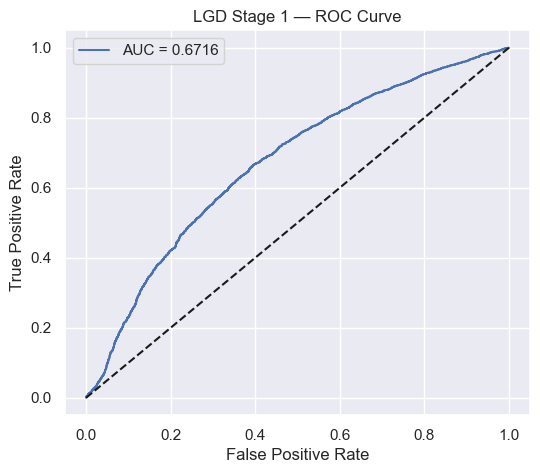

In [10]:
# =========================================================
# STAGE 1 EVALUATION
# =========================================================
# predict_proba returns [P(class=0), P(class=1)] for each row
# We take [:, 1] = probability that recovery DOES happen

s1_proba = lgd_s1.model.predict_proba(X_test.values)[:, 1]
auc_s1   = roc_auc_score(y1_test.values, s1_proba)
print(f'Stage 1 AUROC: {auc_s1:.4f}')

# Confusion matrix at threshold 0.5
s1_pred = np.where(s1_proba > 0.5, 1, 0)
cm = pd.crosstab(y1_test.values, s1_pred, rownames=['Actual'], colnames=['Predicted'])
print('\nConfusion Matrix (threshold=0.5):')
print(cm)

accuracy = (cm.iloc[0, 0] + cm.iloc[1, 1]) / cm.values.sum()
print(f'\nAccuracy: {accuracy:.4f}')

# ROC Curve plot
fpr, tpr, _ = roc_curve(y1_test.values, s1_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc_s1:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LGD Stage 1 — ROC Curve')
plt.legend()
plt.show()

## Stage 2 — Linear Regression (How much was recovered?)

Trained ONLY on loans where recovery actually happened (rec_flag == 1).  
We are now predicting the actual amount — a regression problem, not classification.  
But at prediction time, Stage 2 is applied to ALL loans (combined with Stage 1 probability).

In [11]:
# =========================================================
# LGD STAGE 2 — LINEAR REGRESSION
# =========================================================
# Filter training data: only loans where recovery > 0
# Including zeros here would drag the regression toward zero
# and underpredict recovery for loans that DO have recovery

mask_train = y1_train.values == 1
mask_test  = y1_test.values  == 1

X_s2_train = X_train.values[mask_train].astype(float)
y_s2_train = y2_train.values[mask_train]

X_s2_test  = X_test.values[mask_test].astype(float)
y_s2_test  = y2_test.values[mask_test]

print(f'Stage 2 train (positive recovery only): {X_s2_train.shape[0]}')
print(f'Stage 2 test  (positive recovery only): {X_s2_test.shape[0]}')

lgd_s2 = LinearRegWithPValues()
lgd_s2.fit(X_s2_train, y_s2_train)

# Summary table
s2_summary = pd.DataFrame({'Feature': feat_names, 'Coefficient': lgd_s2.coef_})
s2_summary.index = s2_summary.index + 1
s2_summary.loc[0] = ['Intercept', lgd_s2.intercept_]
s2_summary = s2_summary.sort_index()
s2_summary['p_value'] = np.append(np.nan, np.array(lgd_s2.p)).round(4)

print('\nStage 2 — Significant features (p < 0.05):')
print(s2_summary[s2_summary['p_value'] < 0.05].to_string())

Stage 2 train (positive recovery only): 18681
Stage 2 test  (positive recovery only): 4619

Stage 2 — Significant features (p < 0.05):
                          Feature   Coefficient  p_value
1                         grade:A -9.397457e-02   0.0000
2                         grade:B -7.345430e-02   0.0000
3                         grade:C -5.470079e-02   0.0000
4                         grade:D -4.295280e-02   0.0000
5                         grade:E -2.315435e-02   0.0000
6                         grade:F -1.044471e-02   0.0307
8             home_ownership:NONE  2.129277e-01   0.0000
10             home_ownership:OWN  6.009656e-03   0.0163
15            purpose:educational  5.828198e-02   0.0000
25                purpose:wedding  2.312476e-02   0.0023
26          initial_list_status:w  1.425079e-02   0.0000
29        months_since_issue_date -1.565630e-03   0.0000
30  months_since_earliest_cr_line  3.198116e-05   0.0007
32                       int_rate -3.242603e-03   0.0000
33        

Stage 2 R²:          0.0944
Stage 2 RMSE:        0.0930
Stage 2 Correlation: 0.3076


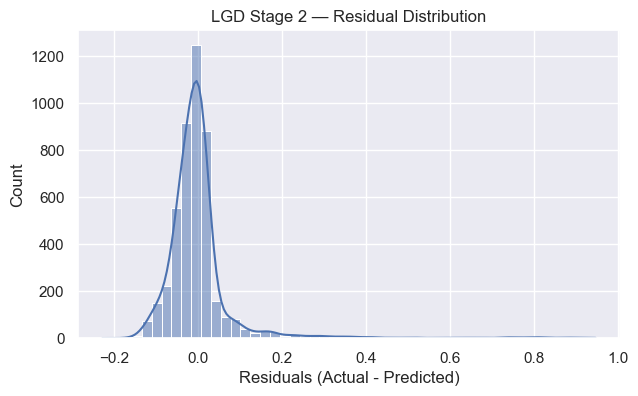

In [12]:
# =========================================================
# STAGE 2 EVALUATION
# =========================================================

y_s2_pred = np.clip(lgd_s2.predict(X_s2_test), 0, 1)

r2_s2   = r2_score(y_s2_test, y_s2_pred)
rmse_s2 = np.sqrt(mean_squared_error(y_s2_test, y_s2_pred))
corr_s2 = np.corrcoef(y_s2_test, y_s2_pred)[0, 1]

print(f'Stage 2 R²:          {r2_s2:.4f}')
print(f'Stage 2 RMSE:        {rmse_s2:.4f}')
print(f'Stage 2 Correlation: {corr_s2:.4f}')

# Residual distribution — should be roughly centred around 0
plt.figure(figsize=(7, 4))
sns.histplot(y_s2_test - y_s2_pred, bins=50, kde=True)
plt.title('LGD Stage 2 — Residual Distribution')
plt.xlabel('Residuals (Actual - Predicted)')
plt.show()

## Combining Stage 1 + Stage 2 → Final LGD

Predicted LGD stats:
count    8180.0000
mean        0.9372
std         0.0145
min         0.7486
25%         0.9287
50%         0.9379
75%         0.9463
max         1.0000
dtype: float64

Final LGD RMSE:        0.0909
Final LGD Correlation: 0.0888


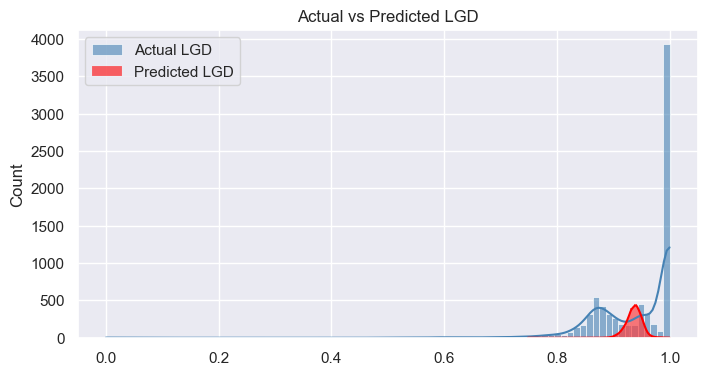

In [13]:
# =========================================================
# FINAL LGD ON TEST SET
# =========================================================
# Stage 1 applied to ALL test loans → P(recovery)
# Stage 2 applied to ALL test loans → predicted recovery amount
# Combined recovery = P(recovery) × amount
# LGD = 1 − combined recovery, clipped to [0, 1]

s1_all = lgd_s1.model.predict_proba(X_test.values)[:, 1]
s2_all = np.clip(lgd_s2.predict(X_test.values), 0, 1)

rec_pred   = np.clip(s1_all * s2_all, 0, 1)
lgd_pred   = 1 - rec_pred
lgd_actual = 1 - y2_test.values

rmse_lgd = np.sqrt(mean_squared_error(lgd_actual, lgd_pred))
corr_lgd = np.corrcoef(lgd_actual, lgd_pred)[0, 1]

print('Predicted LGD stats:')
print(pd.Series(lgd_pred).describe().round(4))
print(f'\nFinal LGD RMSE:        {rmse_lgd:.4f}')
print(f'Final LGD Correlation: {corr_lgd:.4f}')

# Actual vs Predicted distribution
plt.figure(figsize=(8, 4))
sns.histplot(lgd_actual, color='steelblue', label='Actual LGD',    kde=True, alpha=0.6)
sns.histplot(lgd_pred,   color='red',       label='Predicted LGD', kde=True, alpha=0.6)
plt.title('Actual vs Predicted LGD')
plt.legend()
plt.show()

In [14]:
import pickle

# Save LGD Stage 1
with open(r'C:\Users\amit_\Github\credit-portfolio-vasicek-simulation\data\processed\lgd_stage1_model.pkl', 'wb') as f:
    pickle.dump(lgd_s1, f)

# Save LGD Stage 2
with open(r'C:\Users\amit_\Github\credit-portfolio-vasicek-simulation\data\processed\lgd_stage2_model.pkl', 'wb') as f:
    pickle.dump(lgd_s2, f)

print('LGD models saved.')

LGD models saved.


---
# PART 7 — EAD MODEL

## What is EAD?

EAD = Exposure at Default = how much of the loan was still outstanding when the borrower defaulted.

We use the **Credit Conversion Factor (CCF)**:
$$\text{CCF} = \frac{\text{funded\_amnt} - \text{total\_rec\_prncp}}{\text{funded\_amnt}}$$

Then: EAD = CCF × funded_amnt

- CCF = 1.0 → borrower paid back nothing before defaulting  
- CCF = 0.3 → borrower had repaid 70% before defaulting

CCF distribution is more spread out (no spike at 0), so a **single linear regression** works fine here — no need for a two-stage model.

In [15]:
# =========================================================
# EAD MODEL — LINEAR REGRESSION ON CCF
# =========================================================
# Same feature set as LGD, target is CCF instead of recovery_rate
# Same 80/20 split

X_ead = df_model[features_final].astype(float)
y_ead = df_model['CCF']

X_ead_train, X_ead_test, y_ead_train, y_ead_test = train_test_split(
    X_ead, y_ead, test_size=0.2, random_state=42
)

ead_model = LinearRegWithPValues()
ead_model.fit(X_ead_train.values, y_ead_train.values)

# Summary table
ead_summary = pd.DataFrame({'Feature': feat_names, 'Coefficient': ead_model.coef_})
ead_summary.index = ead_summary.index + 1
ead_summary.loc[0] = ['Intercept', ead_model.intercept_]
ead_summary = ead_summary.sort_index()
ead_summary['p_value'] = np.append(np.nan, np.array(ead_model.p)).round(4)

print('EAD Model — Significant features (p < 0.05):')
print(ead_summary[ead_summary['p_value'] < 0.05].to_string())

EAD Model — Significant features (p < 0.05):
                                Feature   Coefficient  p_value
1                               grade:A -3.035736e-01   0.0000
2                               grade:B -2.340626e-01   0.0000
3                               grade:C -1.697769e-01   0.0000
4                               grade:D -1.206938e-01   0.0000
5                               grade:E -7.021177e-02   0.0000
6                               grade:F -2.313422e-02   0.0014
7               home_ownership:MORTGAGE -6.140060e-03   0.0046
12  verification_status:Source Verified  9.995850e-03   0.0000
14           purpose:debt_consolidation  1.274918e-02   0.0000
15                  purpose:educational  1.183034e-01   0.0000
16             purpose:home_improvement  2.193950e-02   0.0000
17                        purpose:house  3.018975e-02   0.0107
18               purpose:major_purchase  3.397012e-02   0.0000
19                      purpose:medical  4.056360e-02   0.0000
20        

EAD R²:          0.2787
EAD RMSE:        0.1713
EAD Correlation: 0.5279


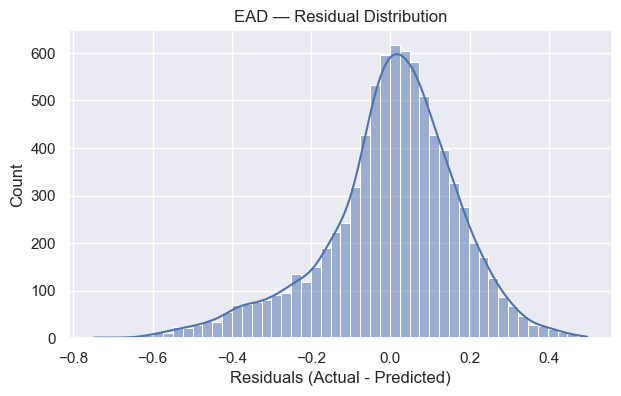


Predicted CCF stats:
count    8180.0000
mean        0.7360
std         0.1055
min         0.3516
25%         0.6612
50%         0.7325
75%         0.8101
max         1.0000
dtype: float64


In [16]:
# =========================================================
# EAD EVALUATION
# =========================================================

y_ead_pred = np.clip(ead_model.predict(X_ead_test.values), 0, 1)

r2_ead   = r2_score(y_ead_test.values, y_ead_pred)
rmse_ead = np.sqrt(mean_squared_error(y_ead_test.values, y_ead_pred))
corr_ead = np.corrcoef(y_ead_test.values, y_ead_pred)[0, 1]

print(f'EAD R²:          {r2_ead:.4f}')
print(f'EAD RMSE:        {rmse_ead:.4f}')
print(f'EAD Correlation: {corr_ead:.4f}')

plt.figure(figsize=(7, 4))
sns.histplot(y_ead_test.values - y_ead_pred, bins=50, kde=True)
plt.title('EAD — Residual Distribution')
plt.xlabel('Residuals (Actual - Predicted)')
plt.show()

print('\nPredicted CCF stats:')
print(pd.Series(y_ead_pred).describe().round(4))

In [17]:
# Save EAD model
import os

os.makedirs('../data/processed', exist_ok=True)
with open('../data/processed/ead_model.pkl', 'wb') as f:
    pickle.dump(ead_model, f)

print('EAD model saved.')

EAD model saved.


---
# PART 8 — EXPECTED CREDIT LOSS (ECL)

$$\text{ECL} = PD \times LGD \times EAD$$

## How we bring the three models together — the correct approach

Each model was built on different data with different features:
- **PD model** → built on full dataset, WoE-transformed features saved in `loan_data_inputs_train/test.csv`
- **LGD and EAD models** → built on defaults only, raw dummy-encoded features

For ECL, we apply **all three models to the full dataset**.  
LGD and EAD are trained on defaults but applied to everyone.  
This is standard Basel IRB practice — every performing loan has a potential LGD and EAD if it defaults.

## The row-alignment problem (what was breaking before)

The error `Length of values (230795) does not match length of index (48896)` happened because:  
- `pd_inputs` had 230,795 rows (full dataset)  
- `df_model` had ~48,896 rows (defaults only)  
- Assigning `df_model['PD'] = pd_inputs['PD'].values` tried to put 230k values into a 48k frame

**Fix:** We build a single ECL dataframe from scratch using the full raw dataset for LGD/EAD,  
and align it with PD predictions row by row.

In [18]:
import pandas as pd
import pickle

# Load PD inputs
pd_inputs = pd.read_csv('../data/processed/pd_inputs_woe.csv')

# Load scaler
scaler = pickle.load(open('../data/processed/pd_scaler.pkl', 'rb'))

# Scale
X_pd_scaled = scaler.transform(pd_inputs)

# Load model
pd_model = pickle.load(open('../data/processed/pd_model_sklearn.pkl', 'rb'))

# Predict PD
pd_inputs['PD'] = pd_model.predict_proba(X_pd_scaled)[:, 1]

# Check
print(pd_inputs['PD'].describe().round(4))

count    230795.0000
mean          0.1910
std           0.1157
min           0.0112
25%           0.1024
50%           0.1662
75%           0.2587
max           0.7713
Name: PD, dtype: float64


In [19]:
# =========================================================
# STEP 2 — APPLY SAME PREPROCESSING TO FULL RAW DATASET
# =========================================================
# We need the same dummy-encoded feature set that LGD and EAD were trained on,
# but now for ALL loans — not just defaults.
# This is identical logic to Part 2, just applied to the full raw file.

raw_full = pd.read_csv('../data/raw/loan_data.csv', low_memory=False)

# Numeric conversions
raw_full['funded_amnt'] = pd.to_numeric(raw_full['funded_amnt'], errors='coerce')
raw_full = raw_full[raw_full['funded_amnt'] > 0].reset_index(drop=True)

raw_full['term_month'] = pd.to_numeric(
    raw_full['term'].str.replace(r'[^0-9]', '', regex=True), errors='coerce'
)

raw_full['emp_length_years'] = (
    raw_full['emp_length'].str.strip()
      .replace({'< 1 year': '0', 'n/a': '0'})
      .str.replace(r'[^0-9]', '', regex=True)
)
raw_full['emp_length_years'] = pd.to_numeric(raw_full['emp_length_years'], errors='coerce')

ref = pd.to_datetime('2016-12-01')

raw_full['earliest_cr_dt'] = pd.to_datetime(raw_full['earliest_cr_line'], format='%b-%y', errors='coerce')
raw_full['months_since_earliest_cr_line'] = (
    (ref.year  - raw_full['earliest_cr_dt'].dt.year)  * 12 +
    (ref.month - raw_full['earliest_cr_dt'].dt.month)
).clip(lower=0)

raw_full['issue_dt'] = pd.to_datetime(raw_full['issue_d'], format='%b-%y', errors='coerce')
raw_full['months_since_issue_date'] = (
    (ref.year  - raw_full['issue_dt'].dt.year)  * 12 +
    (ref.month - raw_full['issue_dt'].dt.month)
)

raw_full['mths_since_last_delinq'] = raw_full['mths_since_last_delinq'].fillna(0)
raw_full['mths_since_last_record'] = raw_full['mths_since_last_record'].fillna(0)
raw_full['total_rev_hi_lim']       = raw_full['total_rev_hi_lim'].fillna(raw_full['total_rev_hi_lim'].median())

# Dummies — same as Part 2
cat_cols   = ['grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status']
raw_full_d = pd.get_dummies(raw_full, columns=cat_cols, prefix=cat_cols, drop_first=False)

rename_map = {}
for col in raw_full_d.columns:
    for p in cat_cols:
        if col.startswith(p + '_'):
            rename_map[col] = col.replace(p + '_', p + ':', 1)
raw_full_d.rename(columns=rename_map, inplace=True)

# Add any missing feature columns as 0
# (safety: some categories may exist in defaults training but not in full data)
for f in features_final:
    if f not in raw_full_d.columns:
        raw_full_d[f] = 0

X_full = raw_full_d[features_final].fillna(0).astype(float)

print(f'Full dataset feature matrix shape: {X_full.shape}')

Full dataset feature matrix shape: (466285, 44)


In [20]:
# =========================================================
# STEP 3 — APPLY LGD MODEL TO FULL DATASET
# =========================================================
# Stage 1: P(any recovery) for every loan in the full portfolio
# Stage 2: expected recovery amount for every loan
# LGD = 1 − clipped(Stage1 × Stage2)

s1_full  = lgd_s1.model.predict_proba(X_full.values)[:, 1]
s2_full  = np.clip(lgd_s2.predict(X_full.values), 0, 1)
rec_full = np.clip(s1_full * s2_full, 0, 1)
lgd_full = 1 - rec_full

print('LGD (full dataset) stats:')
print(pd.Series(lgd_full).describe().round(4))

LGD (full dataset) stats:
count    466285.0000
mean          0.9389
std           0.0139
min           0.0137
25%           0.9310
50%           0.9399
75%           0.9478
max           1.0000
dtype: float64


In [21]:
# =========================================================
# STEP 4 — APPLY EAD MODEL TO FULL DATASET
# =========================================================
# CCF predicted for each loan → EAD = CCF × funded_amnt

ccf_full = np.clip(ead_model.predict(X_full.values), 0, 1)
ead_full = ccf_full * raw_full_d['funded_amnt'].values

print('EAD (full dataset) stats:')
print(pd.Series(ead_full).describe().round(2))

EAD (full dataset) stats:
count    466285.00
mean      10795.72
std        6923.83
min         187.78
25%        5488.60
50%        9191.67
75%       14657.18
max       35000.00
dtype: float64


In [23]:
# =========================================================
# STEP 5 — CHECK ROW ALIGNMENT BEFORE COMBINING
# =========================================================

print(f'PD predictions length: {len(pd_inputs)}')
print(f'LGD predictions length: {len(lgd_full)}')
print(f'EAD predictions length: {len(ead_full)}')

n = min(len(pd_inputs), len(lgd_full))

print(f"\nUsing {n} rows for ECL (aligned by row position)")

PD predictions length: 230795
LGD predictions length: 466285
EAD predictions length: 466285

Using 230795 rows for ECL (aligned by row position)


In [32]:
# --- Clean raw_full_d ---
raw_full_d = raw_full_d.loc[:, ~raw_full_d.columns.duplicated()]

# Remove junk index column
if 'Unnamed: 0' in raw_full_d.columns:
    raw_full_d = raw_full_d.drop(columns=['Unnamed: 0'])

# Ensure id is clean
raw_full_d['id'] = raw_full_d['id'].astype(int)

print("Columns cleaned. id exists:", 'id' in raw_full_d.columns)

Columns cleaned. id exists: True


In [35]:
# =========================================================
# STEP 6 — BUILD ECL USING ID-BASED MERGE (CLEAN VERSION)
# =========================================================

# --- Step 1: Base dataset ---
base_df = raw_full_d[['id', 'funded_amnt', 'issue_d', 'loan_status']].copy()
pd_inputs['id'] = raw_full_d['id'].values[:len(pd_inputs)]
# --- Step 2: Attach PD ---
pd_df = pd_inputs[['id', 'PD']].copy()

# --- Step 3: Create LGD & EAD DataFrames ---
lgd_df = pd.DataFrame({
    'id': raw_full_d['id'].values[:len(lgd_full)],
    'LGD': lgd_full
})

ead_df = pd.DataFrame({
    'id': raw_full_d['id'].values[:len(ead_full)],
    'EAD': ead_full
})

# --- Step 4: Merge everything ---
ecl_df = base_df.merge(pd_df, on='id', how='inner') \
                .merge(lgd_df, on='id', how='inner') \
                .merge(ead_df, on='id', how='inner')

# --- Step 5: Compute ECL ---
ecl_df['ECL'] = ecl_df['PD'] * ecl_df['LGD'] * ecl_df['EAD']

# --- Diagnostics ---
print("ECL dataframe shape:", ecl_df.shape)
print("\nComponent stats:")
print(ecl_df[['PD', 'LGD', 'EAD', 'ECL']].describe().round(4))

ECL dataframe shape: (230795, 8)

Component stats:
                PD          LGD          EAD          ECL
count  230795.0000  230795.0000  230795.0000  230795.0000
mean        0.1910       0.9403    9597.0074    1714.7427
std         0.1157       0.0139    6312.6366    1660.0370
min         0.0112       0.0137     187.7848       9.1781
25%         0.1024       0.9324    4815.1372     586.3064
50%         0.1662       0.9408    7917.4433    1186.8207
75%         0.2587       0.9487   13177.8325    2270.0493
max         0.7713       1.0000   33746.9658   16778.5332


In [36]:
# =========================================================
# STEP 7 — PORTFOLIO SUMMARY
# =========================================================

total_ecl    = ecl_df['ECL'].sum()
total_funded = ecl_df['funded_amnt'].sum()
ecl_pct      = total_ecl / total_funded * 100

print('--- Portfolio ECL Summary ---')
print(f'Total ECL:             {total_ecl:,.0f}')
print(f'Total Funded Amount:   {total_funded:,.0f}')
print(f'ECL as % of Portfolio: {ecl_pct:.2f}%')

print('\nSample loans:')
print(ecl_df[['funded_amnt', 'PD', 'LGD', 'EAD', 'ECL']].head(10).round(4).to_string())

--- Portfolio ECL Summary ---
Total ECL:             395,754,034
Total Funded Amount:   3,161,999,200
ECL as % of Portfolio: 12.52%

Sample loans:
   funded_amnt      PD     LGD        EAD       ECL
0         5000  0.1332  0.9504  2948.9084  373.3477
1         2500  0.0255  0.9444  1933.4720   46.5070
2         2400  0.1597  0.9366  1581.2324  236.4633
3        10000  0.0433  0.9390  6631.0329  269.4694
4         3000  0.1624  0.9597  2131.1731  332.0702
5         5000  0.0771  0.9424  3178.9837  230.9362
6         7000  0.0687  0.9527  5040.9899  330.1332
7         3000  0.0487  0.9229  2045.9588   91.9042
8         5600  0.0181  0.9222  4798.4641   80.1373
9         5375  0.0697  0.9563  3894.1240  259.6058


---
# PART 9 — Year-on-Year ECL Analysis

We break ECL down by the year each loan was issued.

This is useful to:
- See if loss rates were higher in stressed years (e.g. 2008–2009)
- Validate our model — earlier vintage loans should generally show higher ECL
- Identify any year-specific patterns in PD, LGD, or EAD

Since we applied all models to the full portfolio, this is a true portfolio-level year-on-year view.

In [37]:
# =========================================================
# YEAR-ON-YEAR ECL ANALYSIS
# =========================================================

ecl_df['issue_yr'] = pd.to_datetime(
    ecl_df['issue_d'], format='%b-%y', errors='coerce'
).dt.year

yoy = ecl_df.groupby('issue_yr').agg(
    n_loans      = ('ECL', 'count'),
    total_funded = ('funded_amnt', 'sum'),
    total_ecl    = ('ECL', 'sum'),
    avg_pd       = ('PD',  'mean'),
    avg_lgd      = ('LGD', 'mean'),
    avg_ead      = ('EAD', 'mean'),
).reset_index()

yoy['ecl_pct'] = (yoy['total_ecl'] / yoy['total_funded'] * 100).round(2)

print('Year-on-Year ECL Analysis:')
print(yoy.to_string(index=False))

Year-on-Year ECL Analysis:
 issue_yr  n_loans  total_funded    total_ecl   avg_pd  avg_lgd      avg_ead  ecl_pct
     2007      603       4791550 4.355375e+05 0.192485 0.970854  3976.693164     9.09
     2008     2393      19975025 1.805026e+06 0.192117 0.970260  4076.412119     9.04
     2009     5281      51814750 4.786530e+06 0.188118 0.962677  5019.569229     9.24
     2010    12537     126351175 1.367290e+07 0.191402 0.951051  6019.701696    10.82
     2011    21721     257363650 3.092628e+07 0.192016 0.944201  7863.002552    12.02
     2012    53367     717942625 8.620668e+07 0.190988 0.941010  9045.906137    12.01
     2013   134755    1981983500 2.576592e+08 0.190832 0.936869 10729.015054    13.00
     2014      138       1776925 2.619146e+05 0.191088 0.941380 10707.190375    14.74


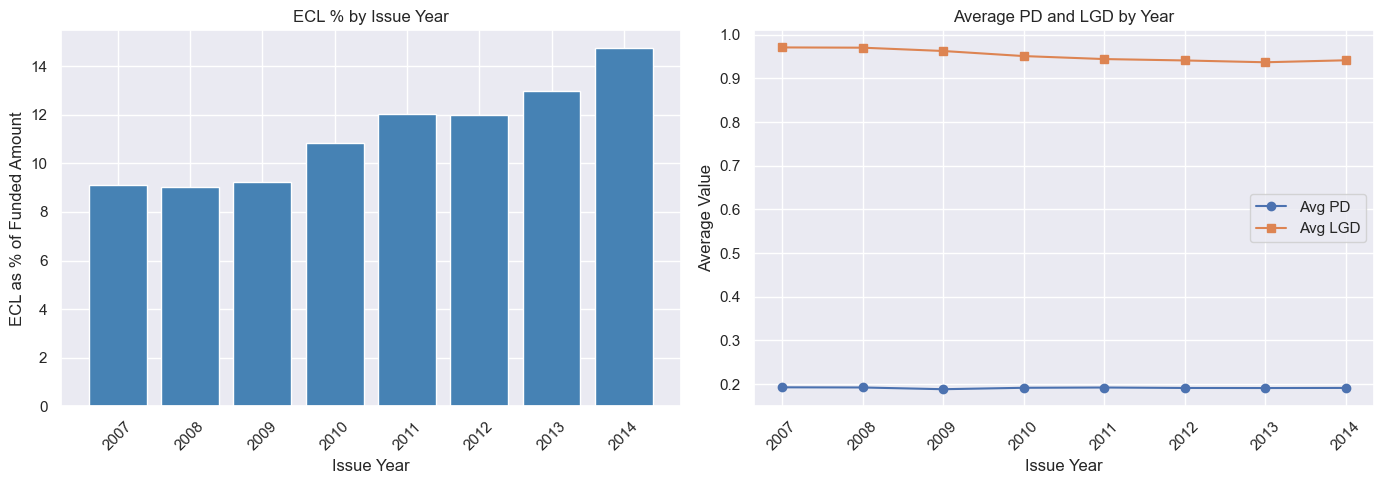

In [38]:
# =========================================================
# PLOT — ECL % AND COMPONENT AVERAGES BY YEAR
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(yoy['issue_yr'], yoy['ecl_pct'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Issue Year')
axes[0].set_ylabel('ECL as % of Funded Amount')
axes[0].set_title('ECL % by Issue Year')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(yoy['issue_yr'], yoy['avg_pd'],  marker='o', label='Avg PD')
axes[1].plot(yoy['issue_yr'], yoy['avg_lgd'], marker='s', label='Avg LGD')
axes[1].set_xlabel('Issue Year')
axes[1].set_ylabel('Average Value')
axes[1].set_title('Average PD and LGD by Year')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
# PART 10 — What's Next: Vasicek Monte Carlo (Preview)

ECL above is the **Expected Loss** — what we lose on average across many scenarios.

Banks need to hold capital against **Unexpected Loss** — the loss in a severe but plausible bad scenario.  
Under Basel, this is the **99.9th percentile of the portfolio loss distribution**.

$$\text{Economic Capital} = \text{Loss at 99.9th percentile} - \text{Expected Loss}$$

To get the full loss distribution, we use the **Vasicek single-factor Monte Carlo** (Notebook 07):

$$A_i = \sqrt{\rho} \cdot Z + \sqrt{1-\rho} \cdot \varepsilon_i$$

Where:
- $Z$ = systematic factor (the economy — same for all borrowers in a scenario)
- $\varepsilon_i$ = idiosyncratic factor (specific to borrower $i$)
- $\rho \approx 0.025$ — estimated in Notebook 05

We will simulate 10,000 economic scenarios, compute portfolio loss in each,  
build the full loss distribution, and extract VaR, CVaR, kurtosis, and economic capital.

---

## End of Notebook 06

✔ LGD two-stage model (logistic + linear) with AUROC, R², RMSE  
✔ EAD model (linear regression on CCF) with R², RMSE  
✔ ECL = PD × LGD × EAD — applied correctly to full portfolio (row-aligned)  
✔ Year-on-year ECL breakdown with plots  
✔ All models saved to `../data/processed/`

**Next: Notebook 07 — Vasicek Single-Factor Monte Carlo Simulation**